In [15]:
# TinyLLM for Sentiment Analysis - From Scratch
# Install required packages (run once)
!pip install torch torchvision --quiet
!pip install numpy pandas scikit-learn --quiet
!pip install matplotlib seaborn tqdm --quiet
print("✓ Packages installed successfully!")
# Imports
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import math
import re
import random
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print()
print(f'🚀 Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✓ Packages installed successfully!

🚀 Using device: cpu


In [16]:
class SimpleTokenizer:
    """Improved tokenizer with normalization and special tokens"""

    def __init__(self, vocab_size=12000):
        self.vocab_size = vocab_size
        self.word2idx = {}
        self.idx2word = {}
        self.special_tokens = ['<PAD>', '<UNK>', '<CLS>', '<EOS>']

    def _normalize(self, text):
        text = text.lower().strip()
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"[^a-z0-9'!?.,\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    def _tokenize(self, text):
        text = self._normalize(text)
        return re.findall(r"[a-z0-9]+(?:'[a-z0-9]+)?|[!?.,]", text)

    def build_vocab(self, texts):
        """Build vocabulary from training texts"""
        words = []
        for text in texts:
            words.extend(self._tokenize(text))

        word_counts = Counter(words)
        vocab = self.special_tokens + [
            word for word, _ in word_counts.most_common(max(0, self.vocab_size - len(self.special_tokens)))
        ]

        self.word2idx = {word: idx for idx, word in enumerate(vocab)}
        self.idx2word = {idx: word for word, idx in self.word2idx.items()}

        print(f"✓ Vocabulary built: {len(self.word2idx)} tokens")

    def encode(self, text, max_length=128, return_mask=False):
        """Convert text to token indices"""
        tokens = ['<CLS>'] + self._tokenize(text) + ['<EOS>']
        indices = [self.word2idx.get(token, self.word2idx['<UNK>']) for token in tokens]

        if len(indices) > max_length:
            indices = indices[:max_length]
            indices[-1] = self.word2idx['<EOS>']

        attention_mask = [1] * len(indices)

        if len(indices) < max_length:
            pad_len = max_length - len(indices)
            indices += [self.word2idx['<PAD>']] * pad_len
            attention_mask += [0] * pad_len

        if return_mask:
            return indices, attention_mask
        return indices

    def decode(self, indices):
        """Convert token indices back to text"""
        blocked = {'<PAD>', '<CLS>', '<EOS>'}
        words = [self.idx2word.get(idx, '<UNK>') for idx in indices]
        words = [w for w in words if w not in blocked]
        return ' '.join(words)

# Test tokenizer
print("Testing tokenizer...")
test_tokenizer = SimpleTokenizer(vocab_size=100)
test_tokenizer.build_vocab(["hello world", "this is a test"])
encoded, mask = test_tokenizer.encode("hello world", return_mask=True)
print(f"Encoded: {encoded[:10]}")
print(f"Mask:    {mask[:10]}")
print("✓ Tokenizer working!")


Testing tokenizer...
✓ Vocabulary built: 10 tokens
Encoded: [2, 4, 5, 3, 0, 0, 0, 0, 0, 0]
Mask:    [1, 1, 1, 1, 0, 0, 0, 0, 0, 0]
✓ Tokenizer working!


In [17]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding"""
    
    def __init__(self, d_model, max_len=512):
        super().__init__()
        
        # Create positional encoding matrix
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * 
                            (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        self.register_buffer('pe', pe.unsqueeze(0))
        
    def forward(self, x):
        # x: [batch_size, seq_len, d_model]
        return x + self.pe[:, :x.size(1), :]

# Test positional encoding
print("Testing positional encoding...")
pos_enc = PositionalEncoding(d_model=64, max_len=128)
test_input = torch.randn(2, 10, 64)  # batch=2, seq_len=10, d_model=64
output = pos_enc(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}")
print("✓ Positional encoding working!")

Testing positional encoding...
Input shape: torch.Size([2, 10, 64])
Output shape: torch.Size([2, 10, 64])
✓ Positional encoding working!


In [18]:
class MultiHeadAttention(nn.Module):
    """Multi-head self-attention mechanism"""

    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # Linear projections
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.attn_dropout = nn.Dropout(dropout)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """Compute scaled dot-product attention"""
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(~mask, torch.finfo(scores.dtype).min)

        attention_weights = torch.softmax(scores, dim=-1)
        attention_weights = self.attn_dropout(attention_weights)
        output = torch.matmul(attention_weights, V)

        return output, attention_weights

    def forward(self, x, mask=None):
        batch_size = x.size(0)

        Q = self.W_q(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        attn_output, attn_weights = self.scaled_dot_product_attention(Q, K, V, mask)

        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        output = self.W_o(attn_output)

        return output, attn_weights

# Test attention
print("Testing multi-head attention...")
mha = MultiHeadAttention(d_model=64, num_heads=4)
test_input = torch.randn(2, 10, 64)
test_mask = torch.ones(2, 1, 1, 10, dtype=torch.bool)
output, weights = mha(test_input, test_mask)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Attention weights shape: {weights.shape}")
print("✓ Multi-head attention working!")


Testing multi-head attention...
Input shape: torch.Size([2, 10, 64])
Output shape: torch.Size([2, 10, 64])
Attention weights shape: torch.Size([2, 4, 10, 10])
✓ Multi-head attention working!


In [19]:
class FeedForward(nn.Module):
    """Position-wise feed-forward network"""
    
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.GELU()
        
    def forward(self, x):
        return self.linear2(self.dropout(self.activation(self.linear1(x))))

# Test feed-forward
print("Testing feed-forward network...")
ff = FeedForward(d_model=64, d_ff=256)
test_input = torch.randn(2, 10, 64)
output = ff(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}")
print("✓ Feed-forward network working!")

Testing feed-forward network...
Input shape: torch.Size([2, 10, 64])
Output shape: torch.Size([2, 10, 64])
✓ Feed-forward network working!


In [20]:
class TransformerBlock(nn.Module):
    """Single transformer encoder block"""
    
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask=None):
        # Multi-head attention with residual connection
        attn_output, attn_weights = self.attention(x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        
        # Feed-forward with residual connection
        ff_output = self.ff(x)
        x = self.norm2(x + self.dropout(ff_output))
        
        return x, attn_weights

# Test transformer block
print("Testing transformer block...")
block = TransformerBlock(d_model=64, num_heads=4, d_ff=256)
test_input = torch.randn(2, 10, 64)
output, weights = block(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}")
print("✓ Transformer block working!")

Testing transformer block...
Input shape: torch.Size([2, 10, 64])
Output shape: torch.Size([2, 10, 64])
✓ Transformer block working!


In [21]:
class TinyLLM(nn.Module):
    """Improved tiny transformer for sentiment classification"""

    def __init__(self, vocab_size, d_model=256, num_heads=4,
                 num_layers=4, d_ff=1024, max_len=128,
                 num_classes=3, dropout=0.1, pad_idx=0):
        super().__init__()

        self.d_model = d_model
        self.pad_idx = pad_idx

        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_encoding = PositionalEncoding(d_model, max_len)

        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model * 2),
            nn.Linear(d_model * 2, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        """Initialize linear weights"""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x, attention_mask=None):
        if attention_mask is None:
            attention_mask = (x != self.pad_idx).long()

        x = self.token_embedding(x) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)

        attn_mask = attention_mask.unsqueeze(1).unsqueeze(2).bool()

        attention_weights = []
        for block in self.transformer_blocks:
            x, attn_weights = block(x, attn_mask)
            attention_weights.append(attn_weights)

        cls_repr = x[:, 0, :]
        masked_x = x * attention_mask.unsqueeze(-1)
        pooled_repr = masked_x.sum(dim=1) / attention_mask.sum(dim=1, keepdim=True).clamp(min=1)
        features = torch.cat([cls_repr, pooled_repr], dim=-1)

        logits = self.classifier(features)

        return logits, attention_weights

print("✓ TinyLLM model defined successfully!")


✓ TinyLLM model defined successfully!


In [22]:
class SentimentDataset(Dataset):
    """Custom dataset for sentiment analysis"""

    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        tokens, attention_mask = self.tokenizer.encode(text, self.max_length, return_mask=True)

        return {
            'input_ids': torch.tensor(tokens, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(label, dtype=torch.long)
        }

print("✓ Dataset class defined!")


✓ Dataset class defined!


In [23]:
def train_model(model, train_loader, val_loader, epochs=15, lr=3e-4, patience=5, label_smoothing=0.05):
    """Train model with warmup/cosine schedule, mixed precision, and early stopping"""

    model = model.to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=lr,
        epochs=epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.15,
        anneal_strategy='cos',
        div_factor=10,
        final_div_factor=100
    )

    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

    best_val_f1 = 0.0
    best_val_acc = 0.0
    early_stop_counter = 0

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [], 'val_f1': [], 'lr': []
    }

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0

        train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]')
        for batch in train_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                logits, _ = model(input_ids, attention_mask)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            train_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

            train_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100 * train_correct / max(train_total, 1):.2f}%'
            })

        model.eval()
        val_loss = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]')
            for batch in val_bar:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                logits, _ = model(input_ids, attention_mask)
                loss = criterion(logits, labels)

                val_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

                running_acc = 100 * accuracy_score(all_labels, all_preds)
                val_bar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{running_acc:.2f}%'})

        train_acc = 100 * train_correct / max(train_total, 1)
        val_acc = 100 * accuracy_score(all_labels, all_preds)
        val_f1 = 100 * f1_score(all_labels, all_preds, average='macro')

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)

        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        print()
        print('=' * 70)
        print(f'Epoch {epoch+1}/{epochs} Summary:')
        print(f'Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%')
        print(f'Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.2f}% | Val F1: {val_f1:.2f}%')
        print(f'LR: {optimizer.param_groups[0]["lr"]:.6f}')
        print('=' * 70)
        print()

        improved = val_f1 > best_val_f1 or (np.isclose(val_f1, best_val_f1) and val_acc > best_val_acc)
        if improved:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            early_stop_counter = 0
            torch.save(model.state_dict(), 'best_model.pt')
            print(f'✓ Saved best model (Val F1: {val_f1:.2f}% | Val Acc: {val_acc:.2f}%)')
            print()
        else:
            early_stop_counter += 1
            print(f'No improvement for {early_stop_counter}/{patience} epoch(s).')
            print()

        if early_stop_counter >= patience:
            print(f'⏹ Early stopping triggered at epoch {epoch + 1}.')
            break

    print()
    print(f'🎉 Training completed! Best Val F1: {best_val_f1:.2f}% | Best Val Acc: {best_val_acc:.2f}%')
    return history

print("✓ Training function defined!")


✓ Training function defined!


In [24]:
def plot_training_history(history):
    """Plot training and validation metrics"""

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-o', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=11)
    axes[0].set_ylabel('Loss', fontsize=11)
    axes[0].set_title('Loss Curve', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train Acc', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r-o', label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=11)
    axes[1].set_ylabel('Accuracy (%)', fontsize=11)
    axes[1].set_title('Accuracy Curve', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(epochs, history['val_f1'], 'g-o', label='Val Macro F1', linewidth=2)
    axes[2].set_xlabel('Epoch', fontsize=11)
    axes[2].set_ylabel('F1 (%)', fontsize=11)
    axes[2].set_title('Validation Macro-F1', fontsize=13, fontweight='bold')
    axes[2].legend(fontsize=10)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names=['Negative', 'Neutral', 'Positive']):
    """Plot confusion matrix"""

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()

def visualize_attention(model, text, tokenizer, layer_idx=0, head_idx=0, max_length=96):
    """Visualize attention weights for non-padding tokens"""

    model.eval()
    tokens, attn_mask = tokenizer.encode(text, max_length=max_length, return_mask=True)
    input_ids = torch.tensor([tokens]).to(device)
    attention_mask = torch.tensor([attn_mask]).to(device)

    with torch.no_grad():
        _, attention_weights = model(input_ids, attention_mask)

    attn = attention_weights[layer_idx][0, head_idx].cpu().numpy()

    valid_len = int(sum(attn_mask))
    token_ids = tokens[:valid_len]
    token_words = [tokenizer.idx2word.get(idx, '<UNK>') for idx in token_ids]

    attn = attn[:valid_len, :valid_len]

    plt.figure(figsize=(10, 8))
    sns.heatmap(attn, cmap='viridis', xticklabels=token_words,
                yticklabels=token_words, cbar_kws={'label': 'Attention Weight'})
    plt.title(f'Attention Weights - Layer {layer_idx}, Head {head_idx}', fontsize=14, fontweight='bold')
    plt.xlabel('Key', fontsize=12)
    plt.ylabel('Query', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

print("✓ Visualization functions defined!")


✓ Visualization functions defined!


In [25]:
# IMDB dataset loader (binary sentiment)
# Labels: 0 -> Negative, 1 -> Positive

IMDB_DIR = 'aclImdb'  # folder created after extracting aclImdb_v1.tar.gz
LABEL_NAMES = ['Negative', 'Positive']

# Optional limits for faster experiments on CPU. Set to None to use full data.
MAX_TRAIN_SAMPLES = 12000
MAX_TEST_SAMPLES = 5000

# Download/extract (run once in notebook if needed):
# !curl -L -o aclImdb_v1.tar.gz "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
# !tar -xzf aclImdb_v1.tar.gz

def read_imdb_split(base_dir, split='train', max_samples=None):
    texts, labels = [], []

    for class_name, class_label in [('neg', 0), ('pos', 1)]:
        class_dir = os.path.join(base_dir, split, class_name)
        files = [f for f in os.listdir(class_dir) if f.endswith('.txt')]

        for fname in files:
            fpath = os.path.join(class_dir, fname)
            with open(fpath, 'r', encoding='utf-8', errors='ignore') as f:
                text = f.read().strip()
            if text:
                texts.append(text)
                labels.append(class_label)

    indices = np.arange(len(texts))
    np.random.shuffle(indices)

    if max_samples is not None:
        indices = indices[:max_samples]

    texts = [texts[i] for i in indices]
    labels = [labels[i] for i in indices]
    return texts, labels

if not os.path.isdir(IMDB_DIR):
    raise FileNotFoundError(
        f"'{IMDB_DIR}' not found. Download IMDB dataset and extract it in the notebook working directory."
    )

print('📥 Loading IMDB dataset...')
train_texts_full, train_labels_full = read_imdb_split(IMDB_DIR, split='train', max_samples=MAX_TRAIN_SAMPLES)
test_texts, test_labels = read_imdb_split(IMDB_DIR, split='test', max_samples=MAX_TEST_SAMPLES)

print('📊 IMDB Dataset Loaded:')
print(f"Train(full): {len(train_texts_full)}")
print(f"Test:       {len(test_texts)}")
print(f"Train label counts: {Counter(train_labels_full)}")
print(f"Test label counts:  {Counter(test_labels)}")


📥 Loading IMDB dataset...
📊 IMDB Dataset Loaded:
Train(full): 12000
Test:       5000
Train label counts: Counter({0: 6047, 1: 5953})
Test label counts:  Counter({1: 2501, 0: 2499})


In [26]:
print("🔧 Preparing data...")

# Create validation split from official training set
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts_full, train_labels_full,
    test_size=0.1,
    random_state=SEED,
    stratify=train_labels_full
)

print()
print("✓ Data split:")
print(f"  Training samples:   {len(train_texts)}")
print(f"  Validation samples: {len(val_texts)}")
print(f"  Test samples:       {len(test_texts)}")

# Build tokenizer from train only
print()
print("🔤 Building vocabulary...")
tokenizer = SimpleTokenizer(vocab_size=20000)
tokenizer.build_vocab(train_texts)

import json
with open('tokenizer_vocab.json', 'w') as f:
    json.dump(tokenizer.word2idx, f)
print("✓ Tokenizer vocabulary saved!")

MAX_LENGTH = 160
train_dataset = SentimentDataset(train_texts, train_labels, tokenizer, max_length=MAX_LENGTH)
val_dataset = SentimentDataset(val_texts, val_labels, tokenizer, max_length=MAX_LENGTH)
test_dataset = SentimentDataset(test_texts, test_labels, tokenizer, max_length=MAX_LENGTH)

BATCH_SIZE = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print()
print("✓ DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max length: {MAX_LENGTH}")


🔧 Preparing data...

✓ Data split:
  Training samples:   10800
  Validation samples: 1200
  Test samples:       5000

🔤 Building vocabulary...
✓ Vocabulary built: 20000 tokens
✓ Tokenizer vocabulary saved!

✓ DataLoaders created:
  Train batches: 338
  Val batches:   38
  Test batches:  157
  Batch size: 32
  Max length: 160


In [27]:
print("🤖 Initializing TinyLLM model...")
print()

# Model configuration
MODEL_CONFIG = {
    'vocab_size': len(tokenizer.word2idx),
    'd_model': 192,
    'num_heads': 6,
    'num_layers': 4,
    'd_ff': 768,
    'max_len': MAX_LENGTH,
    'num_classes': len(LABEL_NAMES),
    'dropout': 0.2,
    'pad_idx': tokenizer.word2idx['<PAD>']
}

# Create model
model = TinyLLM(**MODEL_CONFIG)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("📊 Model Statistics:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size: ~{total_params * 4 / (1024**2):.2f} MB")
print()
print("  Configuration:")
for key, value in MODEL_CONFIG.items():
    print(f"    {key}: {value}")

model = model.to(device)
print()
print(f"✓ Model moved to {device}")


🤖 Initializing TinyLLM model...

📊 Model Statistics:
  Total parameters: 5,694,530
  Trainable parameters: 5,694,530
  Model size: ~21.72 MB

  Configuration:
    vocab_size: 20000
    d_model: 192
    num_heads: 6
    num_layers: 4
    d_ff: 768
    max_len: 160
    num_classes: 2
    dropout: 0.2
    pad_idx: 0

✓ Model moved to cpu


In [28]:
print("🚀 Starting training...")
print()

# Training configuration
EPOCHS = 8
LEARNING_RATE = 3e-4
PATIENCE = 3

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    patience=PATIENCE,
    label_smoothing=0.05
)

print()
print("✅ Training completed!")


🚀 Starting training...



Epoch 1/8 [Val]: 100%|██████████| 38/38 [00:02<00:00, 16.56it/s, loss=0.6155, acc=64.00%]



Epoch 1/8 Summary:
Train Loss: 0.7401 | Train Acc: 51.69%
Val Loss:   0.6363 | Val Acc:   64.00% | Val F1: 62.50%
LR: 0.000282

✓ Saved best model (Val F1: 62.50% | Val Acc: 64.00%)



Epoch 2/8 [Val]: 100%|██████████| 38/38 [00:02<00:00, 17.12it/s, loss=0.5526, acc=72.42%]



Epoch 2/8 Summary:
Train Loss: 0.6138 | Train Acc: 67.51%
Val Loss:   0.5783 | Val Acc:   72.42% | Val F1: 72.37%
LR: 0.000290

✓ Saved best model (Val F1: 72.37% | Val Acc: 72.42%)



...


Epoch 6/8 Summary:
Train Loss: 0.5086 | Train Acc: 76.65%
Val Loss:   0.5453 | Val Acc:   75.25% | Val F1: 75.15%
LR: 0.000060

No improvement for 1/3 epoch(s).



Epoch 7/8 [Val]: 100%|██████████| 38/38 [00:02<00:00, 14.86it/s, loss=0.5038, acc=76.25%]



Epoch 7/8 Summary:
Train Loss: 0.4995 | Train Acc: 77.05%
Val Loss:   0.5285 | Val Acc:   76.25% | Val F1: 76.22%
LR: 0.000016

✓ Saved best model (Val F1: 76.22% | Val Acc: 76.25%)



Epoch 8/8 [Val]: 100%|██████████| 38/38 [00:02<00:00, 15.46it/s, loss=0.5003, acc=76.50%]


Epoch 8/8 Summary:
Train Loss: 0.4903 | Train Acc: 78.28%
Val Loss:   0.5329 | Val Acc:   76.50% | Val F1: 76.50%
LR: 0.000000

✓ Saved best model (Val F1: 76.50% | Val Acc: 76.50%)


🎉 Training completed! Best Val F1: 76.50% | Best Val Acc: 76.50%

✅ Training completed!


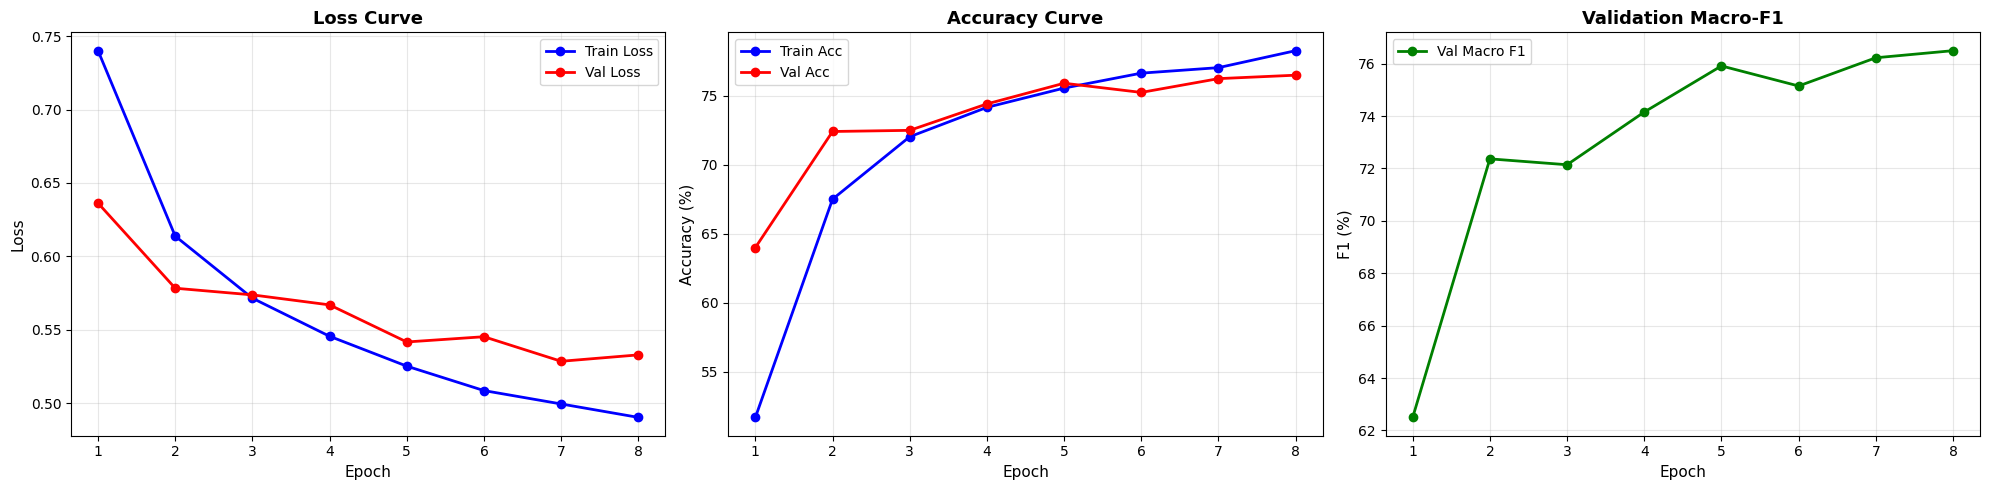


🏆 Best Results:
  Epoch: 8
  Train Acc: 78.28%
  Val Acc: 76.50%
  Val F1: 76.50%
  Val Loss: 0.5329


In [29]:
# Plot training history
plot_training_history(history)

# Print best results
best_epoch = np.argmax(history['val_f1'])
print()
print("🏆 Best Results:")
print(f"  Epoch: {best_epoch + 1}")
print(f"  Train Acc: {history['train_acc'][best_epoch]:.2f}%")
print(f"  Val Acc: {history['val_acc'][best_epoch]:.2f}%")
print(f"  Val F1: {history['val_f1'][best_epoch]:.2f}%")
print(f"  Val Loss: {history['val_loss'][best_epoch]:.4f}")


📊 Evaluating model on IMDB test set...



Evaluating: 100%|██████████| 157/157 [00:10<00:00, 15.22it/s]

Classification Report (Test Set):
              precision    recall  f1-score   support

    Negative     0.7566    0.7763    0.7663      2499
    Positive     0.7705    0.7505    0.7604      2501

    accuracy                         0.7634      5000
   macro avg     0.7636    0.7634    0.7634      5000
weighted avg     0.7636    0.7634    0.7634      5000

Test Accuracy: 76.34%
Test Macro-F1: 76.34%


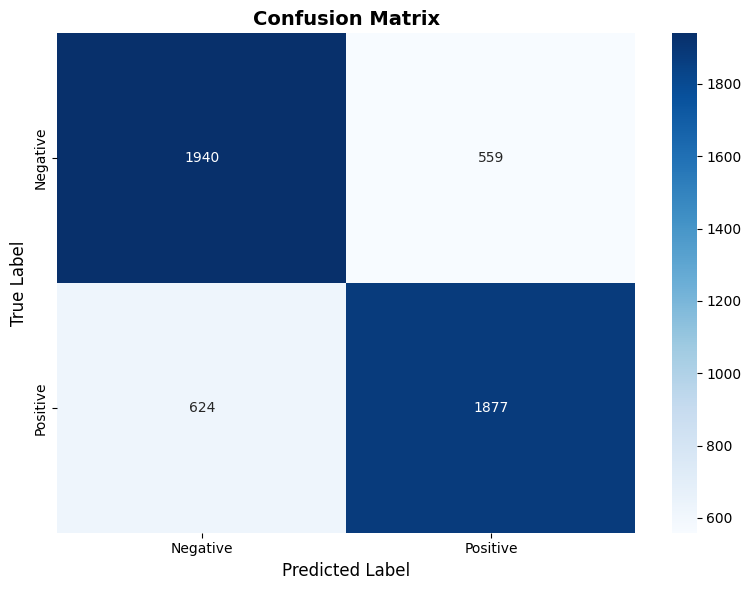

In [30]:
print("📊 Evaluating model on IMDB test set...")
print()

# Load best model
model.load_state_dict(torch.load('best_model.pt', map_location=device))
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Evaluating'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        logits, _ = model(input_ids, attention_mask)
        probs = torch.softmax(logits, dim=1)
        predicted = torch.argmax(probs, dim=1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

class_names = LABEL_NAMES
print('=' * 60)
print('Classification Report (Test Set):')
print('=' * 60)
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

acc = accuracy_score(all_labels, all_preds) * 100
macro_f1 = f1_score(all_labels, all_preds, average='macro') * 100
print(f"Test Accuracy: {acc:.2f}%")
print(f"Test Macro-F1: {macro_f1:.2f}%")

plot_confusion_matrix(all_labels, all_preds, class_names)


In [31]:
def predict_sentiment(text, model, tokenizer, max_length=160):
    """Predict sentiment for a single text"""
    model.eval()

    tokens, mask = tokenizer.encode(text, max_length=max_length, return_mask=True)
    input_ids = torch.tensor([tokens]).to(device)
    attention_mask = torch.tensor([mask]).to(device)

    with torch.no_grad():
        logits, _ = model(input_ids, attention_mask)
        probs = torch.softmax(logits, dim=1)
        predicted = torch.argmax(probs, dim=1)

    sentiment_map = {0: 'Negative', 1: 'Positive'}

    print('=' * 60)
    print(f"Text: {text}")
    print('=' * 60)
    print(f"Predicted Sentiment: {sentiment_map[predicted.item()]}")
    print(f"Confidence: {probs[0][predicted].item()*100:.2f}%")
    print()
    print('Probability Distribution:')
    print(f"  Negative: {probs[0][0].item()*100:.2f}%")
    print(f"  Positive: {probs[0][1].item()*100:.2f}%")
    print('=' * 60)
    print()

    return predicted.item(), probs[0].cpu().numpy()

# Test examples
test_examples = [
    "This is one of the best movies I have watched in years.",
    "Terrible film. Boring plot and weak acting.",
    "Excellent storytelling, strong performances, and great pacing.",
    "I regret watching this. It was painfully slow and dull.",
]

print("🧪 Testing model predictions:")
print()
for text in test_examples:
    predict_sentiment(text, model, tokenizer, max_length=MAX_LENGTH)


🧪 Testing model predictions:

Text: This is one of the best movies I have watched in years.
Predicted Sentiment: Positive
Confidence: 95.74%

Probability Distribution:
  Negative: 4.26%
  Positive: 95.74%

Text: Terrible film. Boring plot and weak acting.
Predicted Sentiment: Negative
Confidence: 96.95%

Probability Distribution:
  Negative: 96.95%
  Positive: 3.05%

Text: Excellent storytelling, strong performances, and great pacing.
Predicted Sentiment: Positive
Confidence: 95.85%

Probability Distribution:
  Negative: 4.15%
  Positive: 95.85%

Text: I regret watching this. It was painfully slow and dull.
Predicted Sentiment: Positive
Confidence: 60.80%

Probability Distribution:
  Negative: 39.20%
  Positive: 60.80%



Visualizing attention for: 'This movie was absolutely fantastic and amazing!'


Layer 0, Head 0:


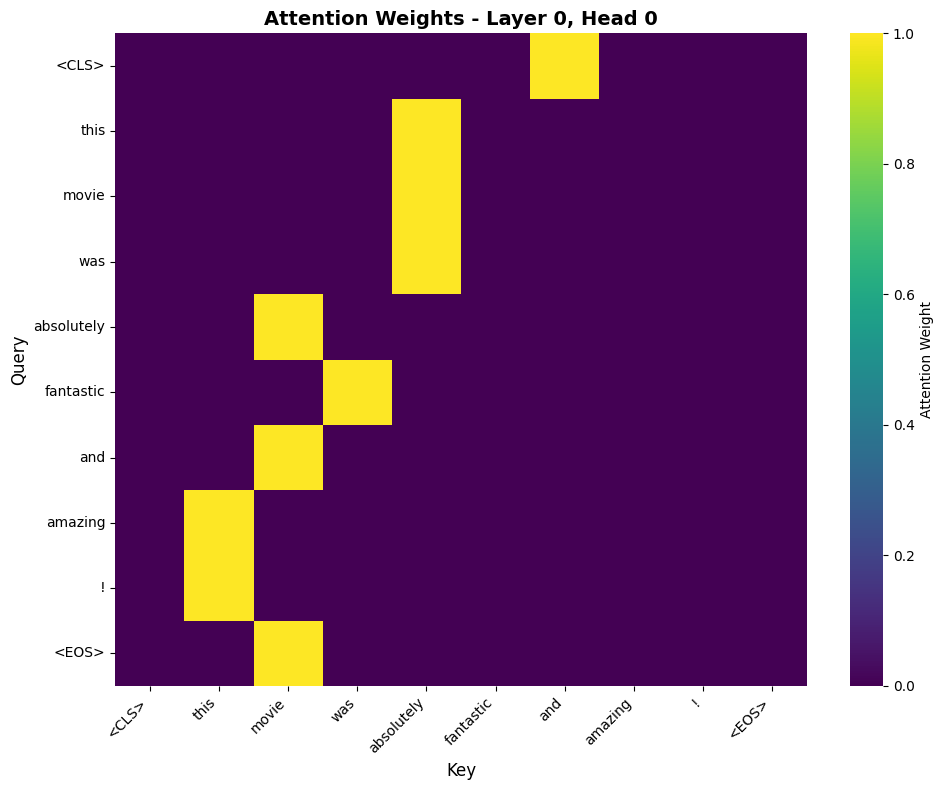


Layer 0, Head 1:


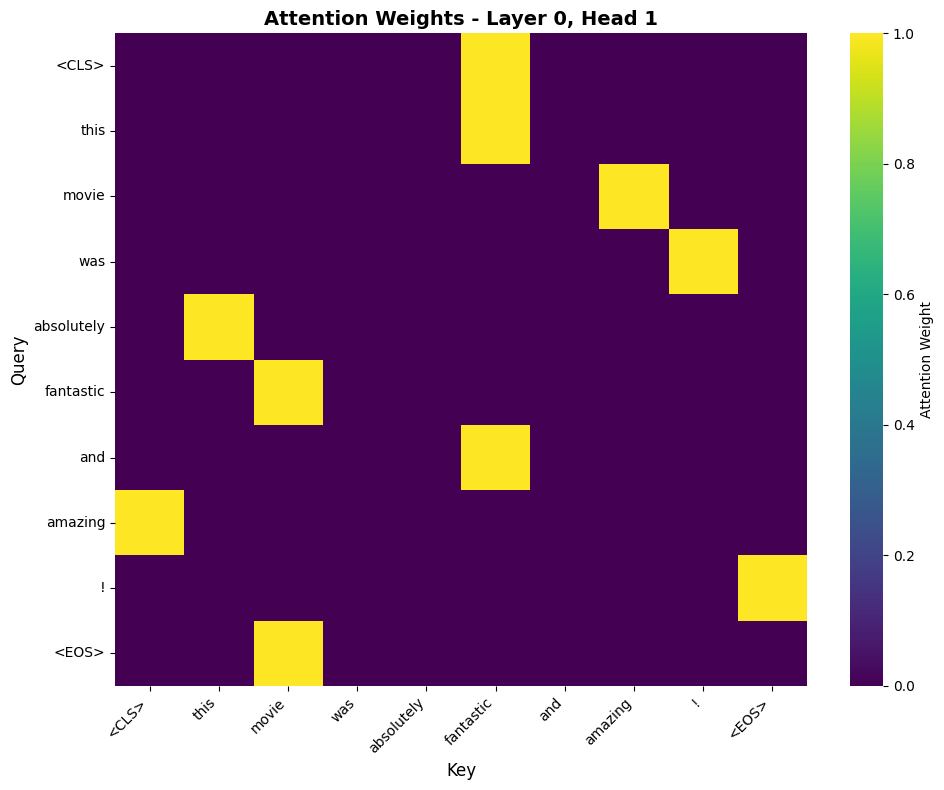


Layer 1, Head 0:


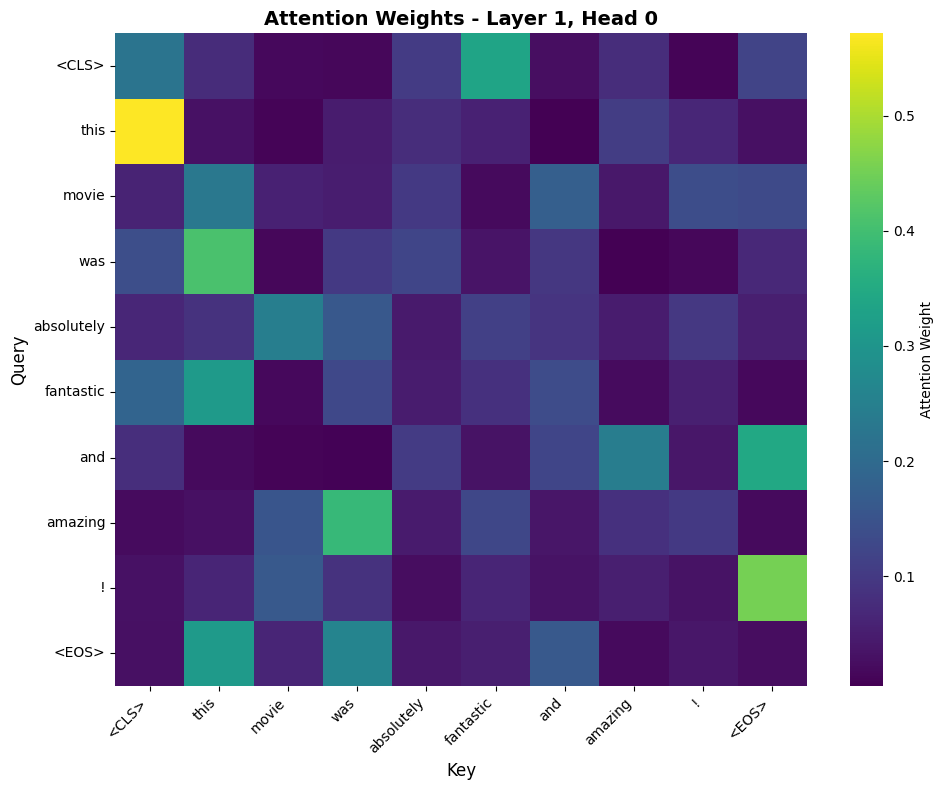


Layer 1, Head 1:


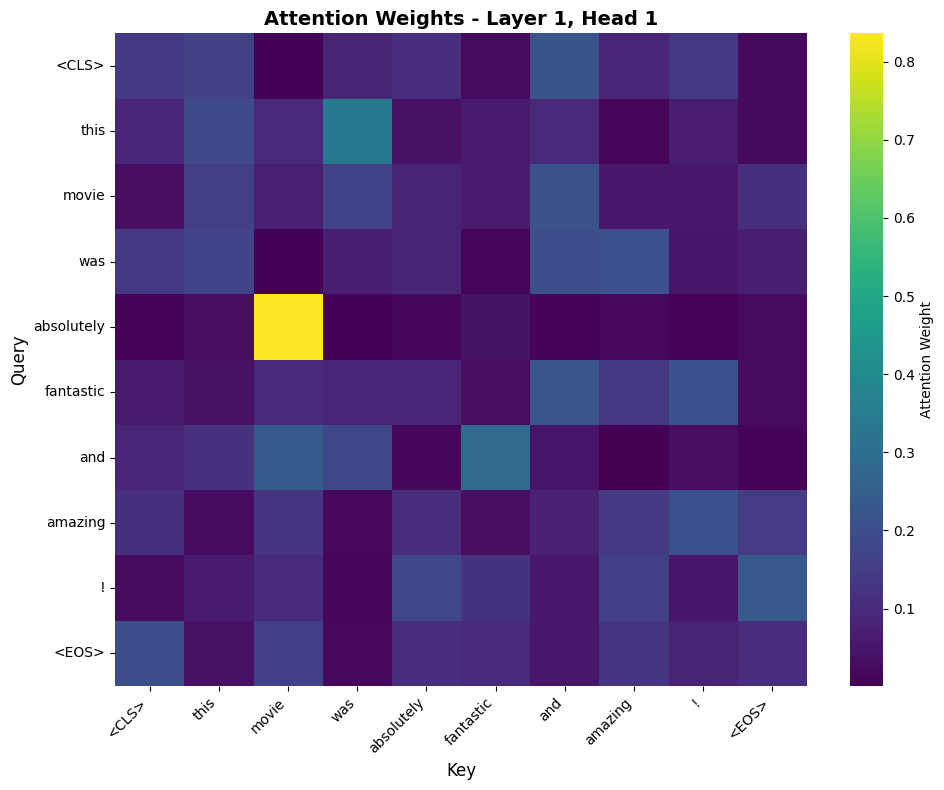

In [32]:
# Visualize attention for an example
example_text = "This movie was absolutely fantastic and amazing!"

print(f"Visualizing attention for: '{example_text}'\n")

# Visualize different layers and heads
for layer in range(min(2, MODEL_CONFIG['num_layers'])):
    for head in range(min(2, MODEL_CONFIG['num_heads'])):
        print(f"\nLayer {layer}, Head {head}:")
        visualize_attention(model, example_text, tokenizer, layer, head)

In [33]:
# Save everything needed for inference
save_dict = {
    'model_state_dict': model.state_dict(),
    'model_config': MODEL_CONFIG,
    'tokenizer_word2idx': tokenizer.word2idx,
    'tokenizer_idx2word': tokenizer.idx2word,
    'training_history': history,
    'class_names': LABEL_NAMES
}

torch.save(save_dict, 'tinyllm_complete.pt')
print("✅ Complete model saved as 'tinyllm_complete.pt'")

# Save model architecture summary
with open('model_summary.txt', 'w') as f:
    f.write("TinyLLM Model Summary\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Total Parameters: {total_params:,}\n")
    f.write(f"Model Size: ~{total_params * 4 / (1024**2):.2f} MB\n\n")
    f.write("Configuration:\n")
    for key, value in MODEL_CONFIG.items():
        f.write(f"  {key}: {value}\n")
    f.write(f"\nBest Validation Accuracy: {max(history['val_acc']):.2f}%\n")

print("✅ Model summary saved as 'model_summary.txt'")



✅ Complete model saved as 'tinyllm_complete.pt'
✅ Model summary saved as 'model_summary.txt'


In [34]:
# Example: How to load and use the saved model later

def load_model(filepath='tinyllm_complete.pt'):
    """Load saved model for inference"""

    checkpoint = torch.load(filepath, map_location=device)

    tokenizer = SimpleTokenizer()
    tokenizer.word2idx = checkpoint['tokenizer_word2idx']
    tokenizer.idx2word = checkpoint['tokenizer_idx2word']

    model = TinyLLM(**checkpoint['model_config'])
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()

    return model, tokenizer, checkpoint

# Load model
print("Loading saved model...")
loaded_model, loaded_tokenizer, checkpoint = load_model()
print("✅ Model loaded successfully!")

# Test with loaded model
test_text = "This product was bad and I cannot recommend it."
predict_sentiment(test_text, loaded_model, loaded_tokenizer, max_length=checkpoint['model_config']['max_len'])


Loading saved model...
✅ Model loaded successfully!
Text: This product was bad and I cannot recommend it.
Predicted Sentiment: Positive
Confidence: 94.79%

Probability Distribution:
  Negative: 5.21%
  Positive: 94.79%



(1, array([0.05208037, 0.9479196 ], dtype=float32))

In [35]:
# Analyze model performance

print("📈 Model Performance Analysis")
print()
print("="*60)

print()
print("1. Training Summary:")
print(f"   Total Epochs: {len(history['train_loss'])}")
print(f"   Final Train Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"   Final Val Accuracy: {history['val_acc'][-1]:.2f}%")
print(f"   Best Val Accuracy: {max(history['val_acc']):.2f}%")
print(f"   Best Val Macro-F1: {max(history['val_f1']):.2f}%")
print(f"   Best Epoch: {np.argmax(history['val_f1']) + 1}")

print()
print("2. Model Size:")
print(f"   Parameters: {total_params:,}")
print(f"   Size: ~{total_params * 4 / (1024**2):.2f} MB")

print()
print("3. Architecture:")
print(f"   Embedding Dim: {MODEL_CONFIG['d_model']}")
print(f"   Num Layers: {MODEL_CONFIG['num_layers']}")
print(f"   Num Heads: {MODEL_CONFIG['num_heads']}")
print(f"   Vocabulary Size: {MODEL_CONFIG['vocab_size']}")
print(f"   Max Sequence Length: {MODEL_CONFIG['max_len']}")

print()
print("="*60)


📈 Model Performance Analysis


1. Training Summary:
   Total Epochs: 8
   Final Train Accuracy: 78.28%
   Final Val Accuracy: 76.50%
   Best Val Accuracy: 76.50%
   Best Val Macro-F1: 76.50%
   Best Epoch: 8

2. Model Size:
   Parameters: 5,694,530
   Size: ~21.72 MB

3. Architecture:
   Embedding Dim: 192
   Num Layers: 4
   Num Heads: 6
   Vocabulary Size: 20000
   Max Sequence Length: 160

